# 05 · Generador de ECG a partir de un embedding (decoder del embedding 04)

Entrenamos un **decoder** que recibe el **embedding de 258-D del cuaderno 04**
(`[256 features de la CNN | edad_z | sexo]`, modelo 500 Hz) y reconstruye un **latido mediano**
(12 derivaciones × `BEAT_LEN` muestras, ~0.8 s) alineado al pico R. El **encoder permanece
congelado**: solo aprende el decoder a *invertir* esa representación.

Una vez entrenado podemos:
- **Reconstruir**: tomar un ECG real → su embedding → decodificar el latido y comparar.
- **Generar**: muestrear un **embedding aleatorio** de la distribución de embeddings reales
  (una gaussiana ajustada por clase) → decodificar → latido sintético, que repetimos para una
  tira de ritmo de 10 s.

> ⚠️ **Por qué un latido y no los 10 s.** El embedding pasa por un *global average pooling* que
> descarta la información de **fase/tiempo**: no sabe dónde caen los QRS. Si se le pide reconstruir
> los 5000 puntos completos, la salida óptima en MSE es el promedio sobre todas las fases ≈ una
> **línea plana** (fue justo lo que pasó en el primer intento, MSE clavado en ~1.0). Reconstruir el
> **latido mediano alineado al R** elimina ese problema y produce un PQRST realista. Para
> variabilidad latido-a-latido haría falta un VAE/GAN o difusión.

In [1]:
import ast, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DATA   = Path("..") / "data"
MODELS = Path("..") / "models"
CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
LEADS   = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

CFG = dict(fs=500, n=5000, X="X_500hz.npy", ids="ecg_ids_500.npy",
           pt="ecgnet500_best.pt", pools=(4, 4, 4, 2))

torch 2.12.1 | device: mps


## 1 · Split, metadatos y estadísticas de normalización

Mismo *split* por paciente que en los cuadernos anteriores. Cargamos la señal con `mmap` (no
satura RAM) y calculamos `mean/std` por derivación en *train* para normalizar igual que en
entrenamiento — y para **des-normalizar** la salida del decoder a mV al graficar.

In [2]:
df = pd.read_csv(DATA / "ptbxl_clean.csv", index_col="ecg_id")
df["diagnostic_superclass"] = df["diagnostic_superclass"].apply(ast.literal_eval)

groups = df.patient_id.values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
tv_idx, test_idx = next(gss1.split(df, groups=groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
tr_rel, val_rel = next(gss2.split(df.iloc[tv_idx], groups=groups[tv_idx]))
train_idx, val_idx = tv_idx[tr_rel], tv_idx[val_rel]

age = df.age.values.astype(np.float32)
age_imp = np.where(np.isnan(age), np.nanmedian(age[train_idx]), age)
age_z = (age_imp - age_imp[train_idx].mean()) / (age_imp[train_idx].std() + 1e-6)
sex = df.sex.values.astype(np.float32)
META = np.stack([age_z, sex], axis=1).astype(np.float32)
y = df[CLASSES].values.astype(np.float32)

X = np.load(DATA / CFG["X"], mmap_mode="r")          # (N, 5000, 12) en disco
ids = np.load(DATA / CFG["ids"]); assert np.array_equal(ids, df.index.values)
MEAN = X[train_idx].mean(axis=(0, 1)).astype(np.float32)   # (12,)
STD  = X[train_idx].std(axis=(0, 1)).astype(np.float32) + 1e-6
print("señal:", X.shape, "| MEAN/STD por derivación listos")
print(f"train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,}")

señal: (21430, 5000, 12) | MEAN/STD por derivación listos
train 17,137 | val 2,180 | test 2,113


## 2 · Encoder congelado (desde el `.pt`) y embeddings de 258-D

Reconstruimos el modelo 500 Hz desde su `state_dict` (igual que en los cuadernos 03/04), lo
**congelamos** y definimos el embedding `[features(256) | edad | sexo]`.

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, k, pool):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(c_in, c_out, k, padding=k // 2),
                                 nn.BatchNorm1d(c_out), nn.ReLU(), nn.MaxPool1d(pool))
    def forward(self, x): return self.net(x)

class ECGNetFromState(nn.Module):
    def __init__(self, state, pools):
        super().__init__()
        conv_ids = sorted({int(k.split(".")[1]) for k in state
                           if k.startswith("cnn.") and k.endswith("net.0.weight")})
        blocks = []
        for j, i in enumerate(conv_ids):
            c_out, c_in, k = state[f"cnn.{i}.net.0.weight"].shape
            blocks.append(ConvBlock(c_in, c_out, k, pools[j]))
        self.cnn = nn.Sequential(*blocks, nn.AdaptiveAvgPool1d(1))
    def embed(self, sig):
        return self.cnn(sig).flatten(1)              # 256-D

state = torch.load(MODELS / CFG["pt"], map_location=device)
encoder = ECGNetFromState(state, CFG["pools"]).to(device)
encoder.load_state_dict(state, strict=False)         # solo cargamos cnn (la cabeza no se usa)
encoder.eval()
for p in encoder.parameters(): p.requires_grad_(False)
EMB_DIM = 256 + 2                                    # + edad + sexo = 258
print("encoder congelado | EMB_DIM =", EMB_DIM)

@torch.no_grad()
def embed_idx(idx, batch=128):
    out = []
    for i in range(0, len(idx), batch):
        b = idx[i:i+batch]
        xb = (X[b].astype(np.float32) - MEAN) / STD
        sig  = torch.from_numpy(np.ascontiguousarray(xb.transpose(0, 2, 1))).to(device)
        feat = encoder.embed(sig)
        meta = torch.from_numpy(META[b]).to(device)
        out.append(torch.cat([feat, meta], dim=1).cpu().numpy())
    return np.concatenate(out).astype(np.float32)

EMB_TR = embed_idx(train_idx)
EMB_VA = embed_idx(val_idx)
print("embeddings train:", EMB_TR.shape, "| val:", EMB_VA.shape)

encoder congelado | EMB_DIM = 258
embeddings train: (17137, 258) | val: (2180, 258)


## 2·bis — Objetivo: **latido mediano alineado al pico R**

El problema del intento anterior no era el optimizador: el MSE quedaba clavado en ~1.0 (= la
varianza de la señal normalizada) porque el decoder aprendía a predecir **una línea plana**. La
razón es que el embedding sale de un *global average pooling* y **no contiene información de fase**:
no sabe en qué muestra cae cada QRS. Como los latidos están en posiciones distintas en cada ECG, la
salida que minimiza el MSE es el **promedio sobre todas las fases ≈ cero**.

La solución es cambiar el objetivo a algo **que sí esté alineado en fase**: el **latido mediano**.
Detectamos los picos R (energía del QRS con `scipy`), recortamos un ciclo de ~0.8 s centrado en R
de cada latido y tomamos la **mediana** → un PQRST limpio y representativo. Ahora el decoder *puede*
aprenderlo, y al graficar 10 s repetimos ese latido al ritmo deseado. El latido se cachea en disco
(`data/median_beats_500.npy`) para no recalcularlo en cada ejecución.

In [4]:
from scipy.signal import butter, filtfilt, find_peaks

# El embedding (GAP) no tiene fase: no sabe DÓNDE caen los QRS. Por eso, en vez de pedir 10 s
# completos (objetivo imposible -> el MSE colapsa a una línea plana), el objetivo es un LATIDO
# MEDIANO alineado al pico R: detectamos los R en lead II, recortamos ventanas de ~0.8 s
# centradas en R y tomamos la mediana. Ese objetivo SÍ está alineado en fase -> el decoder
# aprende un PQRST real. Para ver 10 s, luego repetimos el latido al ritmo deseado.

BEAT_PRE  = int(0.30 * CFG["fs"])      # 150 muestras antes del pico R
BEAT_POST = int(0.50 * CFG["fs"])      # 250 después
BEAT_LEN  = BEAT_PRE + BEAT_POST       # 400 (~0.8 s, un ciclo PQRST)
assert BEAT_LEN % 16 == 0, "BEAT_LEN debe ser múltiplo de 16 para el upsampling del decoder"
_bb, _ba  = butter(2, [5, 15], btype="band", fs=CFG["fs"])   # banda de energía del QRS

def r_peaks(lead2):
    f = filtfilt(_bb, _ba, lead2); e = f * f                 # energía del QRS
    pk, _ = find_peaks(e, distance=int(0.40 * CFG["fs"]),    # RR mínimo ~150 lpm
                       height=e.mean() + 0.5 * e.std())
    w = int(0.04 * CFG["fs"])                                # refinar al máximo real (±40 ms)
    return np.array([a + int(np.argmax(lead2[a:b]))
                     for p in pk for a, b in [(max(0, p - w), min(len(lead2), p + w + 1))]],
                    dtype=int)

def median_beat(sig):                                        # sig (5000, 12) en mV
    r = r_peaks(sig[:, 1])
    r = r[(r - BEAT_PRE >= 0) & (r + BEAT_POST <= len(sig))]
    if len(r) == 0:
        return None
    beats = np.stack([sig[p - BEAT_PRE:p + BEAT_POST] for p in r])   # (k, L, 12)
    return np.median(beats, axis=0).T.astype(np.float32)            # (12, L)

CACHE, VCACHE = DATA / "median_beats_500.npy", DATA / "median_beats_500_valid.npy"
if CACHE.exists() and VCACHE.exists():
    MEDIAN_BEATS, VALID = np.load(CACHE), np.load(VCACHE)
    print("latidos medianos cargados de caché:", MEDIAN_BEATS.shape)
else:
    N = X.shape[0]
    MEDIAN_BEATS = np.zeros((N, 12, BEAT_LEN), np.float32)
    VALID = np.zeros(N, bool)
    for i in tqdm(range(N), desc="latido mediano"):
        mb = median_beat(X[i].astype(np.float32))
        if mb is not None:
            MEDIAN_BEATS[i], VALID[i] = mb, True
    np.save(CACHE, MEDIAN_BEATS); np.save(VCACHE, VALID)
    print("calculados y cacheados:", MEDIAN_BEATS.shape)
print(f"ECGs con latido válido: {VALID.sum():,}/{len(VALID):,} "
      f"({100*VALID.mean():.1f}%) | objetivo = (12, {BEAT_LEN})")

latido mediano:   0%|          | 0/21430 [00:00<?, ?it/s]

calculados y cacheados: (21430, 12, 400)
ECGs con latido válido: 21,429/21,430 (100.0%) | objetivo = (12, 400)


## 3 · Arquitectura del decoder

Es el "espejo" del encoder: del vector de 258-D expandimos a un mapa corto y lo **sobre-muestreamos
progresivamente** (Upsample lineal + Conv1d) hasta `12 × BEAT_LEN` (un latido, no los 10 s). La
longitud crece 25→50→100→200→400 (cuatro factores ×2). La salida está en el espacio **normalizado**
(z-score), sin activación final.

In [5]:
class ECGDecoder(nn.Module):
    """Del embedding 258-D a un LATIDO mediano (12 × BEAT_LEN), alineado al pico R."""
    def __init__(self, emb_dim=258, base_ch=256, start_len=25, out_ch=12):
        super().__init__()
        self.base_ch, self.start_len = base_ch, start_len
        self.fc = nn.Linear(emb_dim, base_ch * start_len)
        def up(cin, cout):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
                nn.Conv1d(cin, cout, 7, padding=3), nn.BatchNorm1d(cout), nn.ReLU())
        self.net = nn.Sequential(
            up(256, 128),   # 25  -> 50
            up(128,  64),   # 50  -> 100
            up(64,   32),   # 100 -> 200
            up(32,   16),   # 200 -> 400
        )
        self.out = nn.Conv1d(16, out_ch, 7, padding=3)   # -> 12 derivaciones
    def forward(self, z):
        x = self.fc(z).view(-1, self.base_ch, self.start_len)
        x = self.net(x)
        return self.out(x)                                # (B, 12, BEAT_LEN) normalizado

decoder = ECGDecoder(EMB_DIM, start_len=BEAT_LEN // 16).to(device)
with torch.no_grad():
    test_out = decoder(torch.zeros(2, EMB_DIM, device=device))
print("salida del decoder:", tuple(test_out.shape), f"(esperado (2, 12, {BEAT_LEN}))")
print("parámetros decoder:", sum(p.numel() for p in decoder.parameters()))

salida del decoder: (2, 12, 400) (esperado (2, 12, 400))
parámetros decoder: 1964316


## 4 · Entrenamiento (reconstrucción del latido)

Pareja `(embedding 258-D, latido mediano normalizado 12×BEAT_LEN)`. El embedding ya está
precomputado; el latido objetivo sale de `MEDIAN_BEATS` (lo normalizamos por lote). Pérdida =
**MSE + 0.5·MSE de la derivada** (el término de derivada afila el QRS y evita salidas demasiado
suaves). El encoder no se actualiza. Sólo usamos ECGs con latido válido (`VALID`).

**Monitor:** tras **cada 2 épocas** decodificamos **siempre el mismo embedding fijo** (un ECG de
test) y lo comparamos con su latido real, para ver cómo mejora la generación época a época.

train válidos 17,137 | val válidos 2,180
Monitor activo: embedding fijo de ecg_id 13 (lead II), cada 2 épocas



epoch 1/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  1 | train 0.4036 | val 0.3406


epoch 2/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  2 | train 0.3320 | val 0.3622


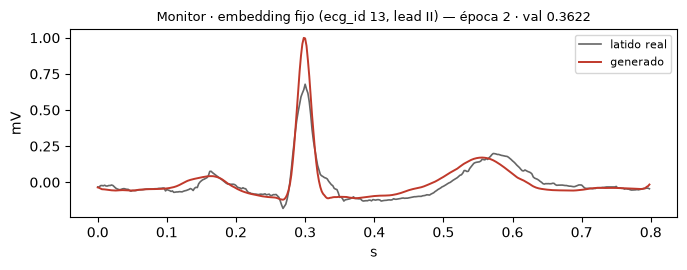

epoch 3/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  3 | train 0.3110 | val 0.3232


epoch 4/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  4 | train 0.2986 | val 0.3048


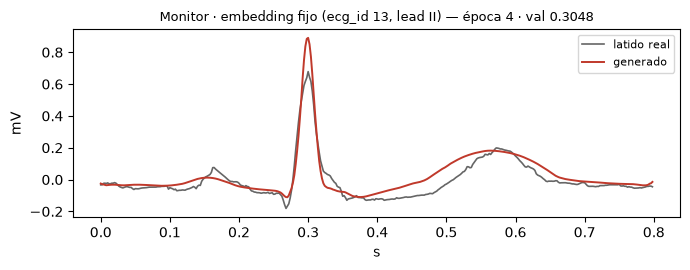

epoch 5/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  5 | train 0.2812 | val 0.3001


epoch 6/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  6 | train 0.2714 | val 0.2967


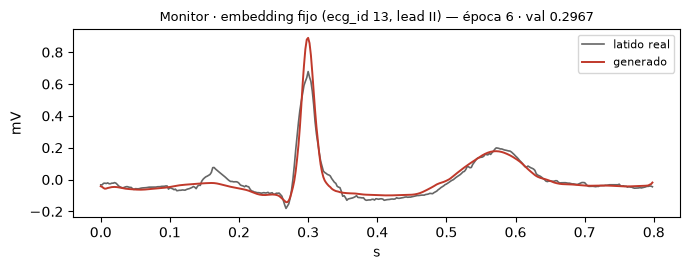

epoch 7/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  7 | train 0.2564 | val 0.2973


epoch 8/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  8 | train 0.2406 | val 0.2757


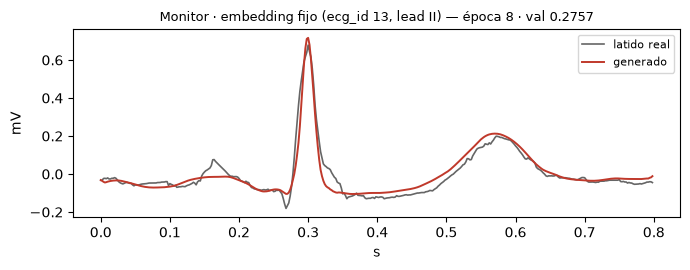

epoch 9/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  9 | train 0.2312 | val 0.2604


epoch 10/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 10 | train 0.2218 | val 0.2679


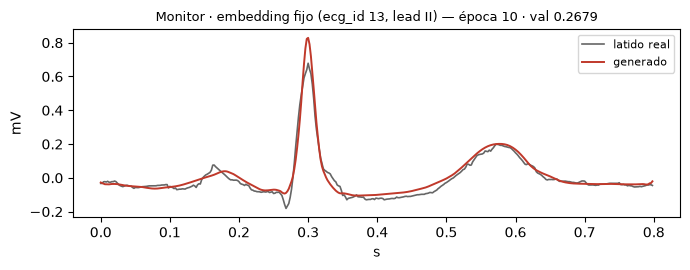

epoch 11/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 11 | train 0.2135 | val 0.2538


epoch 12/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 12 | train 0.2069 | val 0.2479


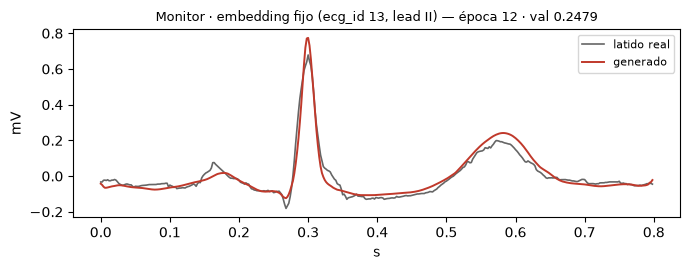

epoch 13/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 13 | train 0.2011 | val 0.2476


epoch 14/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 14 | train 0.1968 | val 0.2452


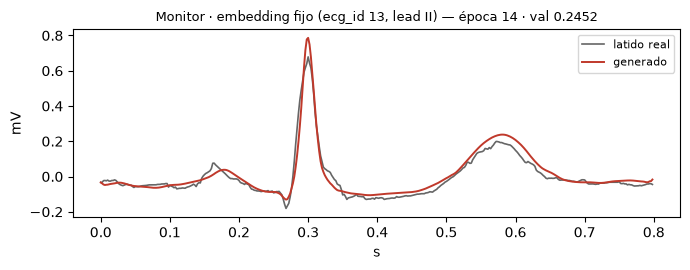

epoch 15/15:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 15 | train 0.1946 | val 0.2439
decoder guardado -> models/ecg_decoder500.pt


In [6]:
class DecDataset(Dataset):
    def __init__(self, idx, emb):
        self.idx, self.emb = idx, emb
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        beat = (MEDIAN_BEATS[j] - MEAN[:, None]) / STD[:, None]    # (12, BEAT_LEN) normalizado
        return torch.from_numpy(self.emb[i]), torch.from_numpy(beat.astype(np.float32))

# Sólo ECGs con latido válido (alineamos embeddings precomputados con la máscara VALID)
trv, vav = VALID[train_idx], VALID[val_idx]
train_idx_v, EMB_TR_v = train_idx[trv], EMB_TR[trv]
val_idx_v,   EMB_VA_v = val_idx[vav],   EMB_VA[vav]
print(f"train válidos {len(train_idx_v):,} | val válidos {len(val_idx_v):,}")

BATCH, EPOCHS = 64, 15
train_dl = DataLoader(DecDataset(train_idx_v, EMB_TR_v), batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(DecDataset(val_idx_v,   EMB_VA_v), batch_size=BATCH)

opt = torch.optim.Adam(decoder.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

def loss_fn(pred, tgt):                       # MSE + derivada (afila el QRS)
    mse = F.mse_loss(pred, tgt)
    dz  = F.mse_loss(pred[..., 1:] - pred[..., :-1], tgt[..., 1:] - tgt[..., :-1])
    return mse + 0.5 * dz

hist = {"train": [], "val": []}

# --- Monitor: SIEMPRE el mismo embedding fijo para ver cómo evoluciona la generación ---
fs = CFG["fs"]
MON_POS  = int(test_idx[VALID[test_idx]][0])          # primer ECG de test con latido válido (fijo)
MON_LEAD = 1                                          # lead II
z_mon    = embed_idx(np.array([MON_POS]))             # (1, 258) embedding fijo
real_beat_mon = MEDIAN_BEATS[MON_POS][MON_LEAD]       # latido real (mV), referencia
t_beat   = np.arange(BEAT_LEN) / fs
MON_EVERY = 2                                         # graficar tras cada 2 épocas

@torch.no_grad()
def _gen_beat_mon():
    decoder.eval()
    rec = decoder(torch.from_numpy(z_mon).to(device)).cpu().numpy()[0]   # (12, L) normalizado
    return rec[MON_LEAD] * STD[MON_LEAD] + MEAN[MON_LEAD]                # -> mV (lead II)

def _plot_mon(ep, va):
    plt.figure(figsize=(7, 2.8))
    plt.plot(t_beat, real_beat_mon, color="black", lw=1.2, alpha=0.6, label="latido real")
    plt.plot(t_beat, _gen_beat_mon(), color="#c0392b", lw=1.4, label="generado")
    plt.title(f"Monitor · embedding fijo (ecg_id {df.index[MON_POS]}, lead II) "
              f"— época {ep} · val {va:.4f}", fontsize=9)
    plt.xlabel("s"); plt.ylabel("mV"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"Monitor activo: embedding fijo de ecg_id {df.index[MON_POS]} (lead II), cada {MON_EVERY} épocas\n")

for ep in range(1, EPOCHS + 1):
    decoder.train(); run = n_seen = 0
    for z, beat in tqdm(train_dl, desc=f"epoch {ep}/{EPOCHS}", leave=False):
        z, beat = z.to(device), beat.to(device)
        opt.zero_grad()
        loss = loss_fn(decoder(z), beat)
        loss.backward(); opt.step()
        run += loss.item() * len(z); n_seen += len(z)
    sched.step(); tr = run / n_seen

    decoder.eval(); vr = vn = 0
    with torch.no_grad():
        for z, beat in val_dl:
            z, beat = z.to(device), beat.to(device)
            vr += loss_fn(decoder(z), beat).item() * len(z); vn += len(z)
    va = vr / vn
    hist["train"].append(tr); hist["val"].append(va)
    print(f"epoch {ep:2d} | train {tr:.4f} | val {va:.4f}")

    if ep % MON_EVERY == 0:                  # tras cada 2 entrenamientos: generar y graficar
        _plot_mon(ep, va)

torch.save(decoder.state_dict(), MODELS / "ecg_decoder500.pt")
print("decoder guardado -> models/ecg_decoder500.pt")

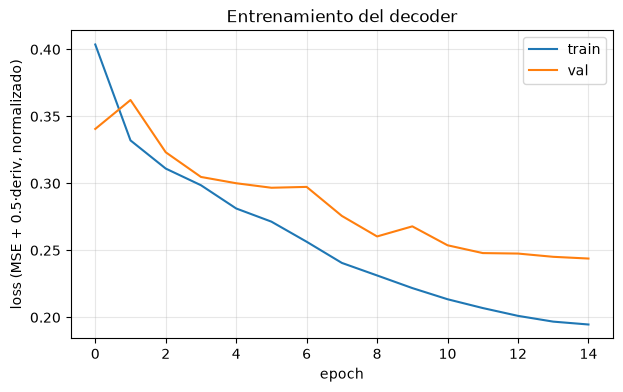

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(hist["train"], label="train"); plt.plot(hist["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("loss (MSE + 0.5·deriv, normalizado)")
plt.title("Entrenamiento del decoder"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 5 · Reconstrucción: latido real vs. decodificado

Tomamos ECGs de *test*, calculamos su embedding y lo decodificamos a un **latido**. Comparamos en mV
el latido generado contra el latido **real** (mediano) de ese ECG, lead II. Ahora sí se espera ver
una morfología PQRST reconocible (P, QRS, T), no una línea plana.

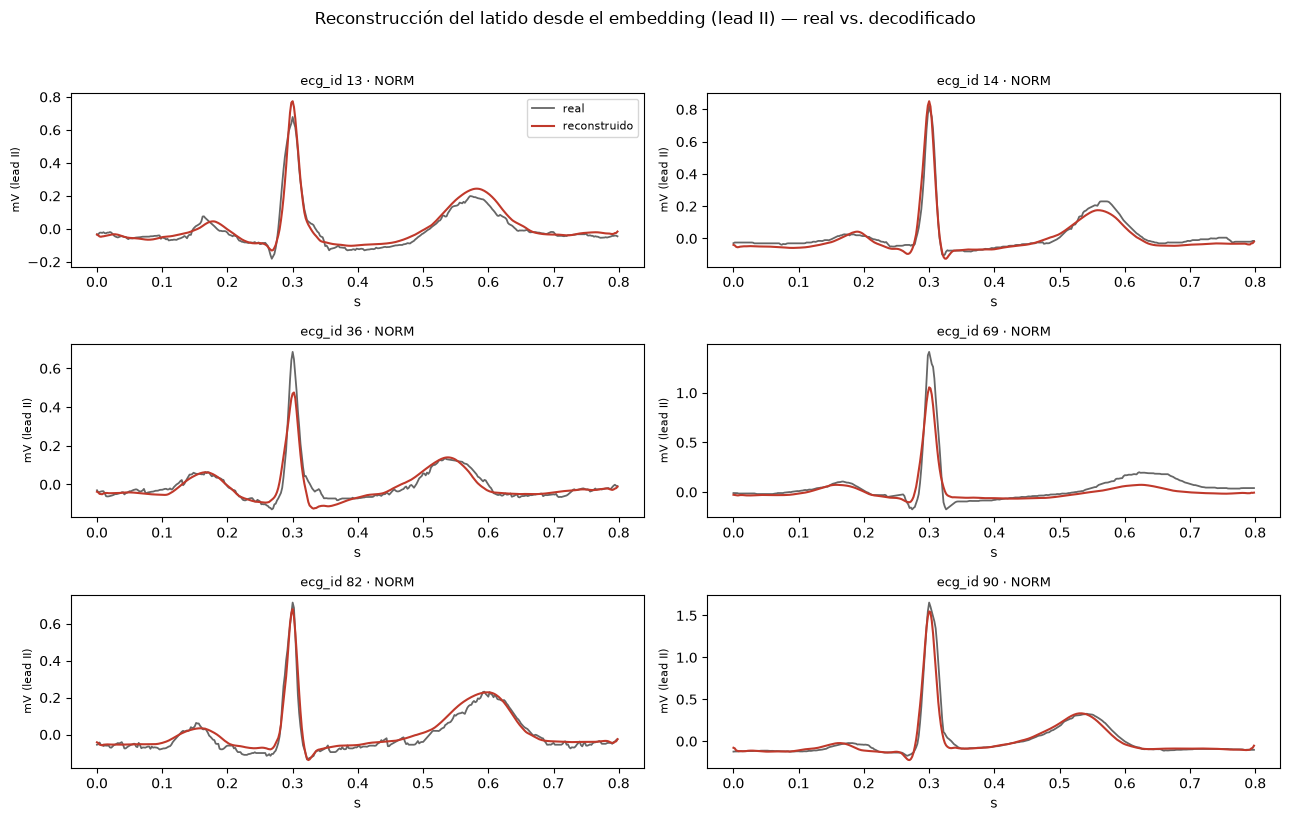

In [8]:
@torch.no_grad()
def decode(z_np):
    """Embedding(s) -> latido(s) en mV. Devuelve (B, 12, BEAT_LEN)."""
    decoder.eval()
    z = torch.from_numpy(np.atleast_2d(z_np).astype(np.float32)).to(device)
    rec = decoder(z).cpu().numpy()                      # (B, 12, BEAT_LEN) normalizado
    return rec * STD[None, :, None] + MEAN[None, :, None]   # -> mV

def tile_beat(beat, seconds=10, bpm=70):
    """Repite un latido (12, BEAT_LEN) en mV al ritmo dado, para ver ~10 s de 'tira de ritmo'."""
    period = max(int(60 / bpm * fs), beat.shape[1])
    total  = int(seconds * fs)
    out = np.repeat(beat[:, -1:], total, axis=1).copy()    # relleno isoeléctrico
    for s in range(0, total, period):
        seg = min(beat.shape[1], total - s)
        out[:, s:s+seg] = beat[:, :seg]
    return out

LEAD = 1
test_v = test_idx[VALID[test_idx]][:6]                  # 6 ECGs de test con latido válido
gen_beats = decode(embed_idx(test_v))                   # (6, 12, BEAT_LEN) en mV

fig, axes = plt.subplots(3, 2, figsize=(13, 8))
for ax, pos, g in zip(axes.flat, test_v, gen_beats):
    ax.plot(t_beat, MEDIAN_BEATS[pos][LEAD], color="black", lw=1.3, alpha=0.6, label="real")
    ax.plot(t_beat, g[LEAD], color="#c0392b", lw=1.5, label="reconstruido")
    sl = df.loc[df.index[pos], "diagnostic_superclass"]
    ax.set_title(f"ecg_id {df.index[pos]} · {', '.join(sl) if sl else '—'}", fontsize=9)
    ax.set_xlabel("s"); ax.set_ylabel("mV (lead II)", fontsize=8)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Reconstrucción del latido desde el embedding (lead II) — real vs. decodificado", y=1.02)
plt.tight_layout(); plt.show()

## 6 · Generar ECG desde un **embedding aleatorio**

Modelamos la distribución de embeddings reales **por clase** con una gaussiana (media + desviación
por dimensión) y muestreamos de ella. Cada muestra es un *embedding aleatorio plausible* de esa
clase → lo decodificamos → ECG generado.

In [9]:
# Estadísticas por clase sobre los embeddings de train (ECGs que tienen esa clase)
EMB_ALL = np.concatenate([EMB_TR, EMB_VA])
Y_ALL   = np.concatenate([y[train_idx], y[val_idx]])
class_stats = {}
for c, name in enumerate(CLASSES):
    sub = EMB_ALL[Y_ALL[:, c] == 1]
    class_stats[name] = (sub.mean(0), sub.std(0) + 1e-6)
    print(f"{name}: {len(sub):,} embeddings  -> media/desv guardadas")

def sample_embedding(class_name, n=1, scale=1.0, rng=None):
    rng = rng or np.random.default_rng(SEED)
    mu, sd = class_stats[class_name]
    return (mu + scale * sd * rng.standard_normal((n, len(mu)))).astype(np.float32)

NORM: 8,588 embeddings  -> media/desv guardadas
MI: 4,958 embeddings  -> media/desv guardadas
STTC: 4,724 embeddings  -> media/desv guardadas
CD: 4,413 embeddings  -> media/desv guardadas
HYP: 2,372 embeddings  -> media/desv guardadas


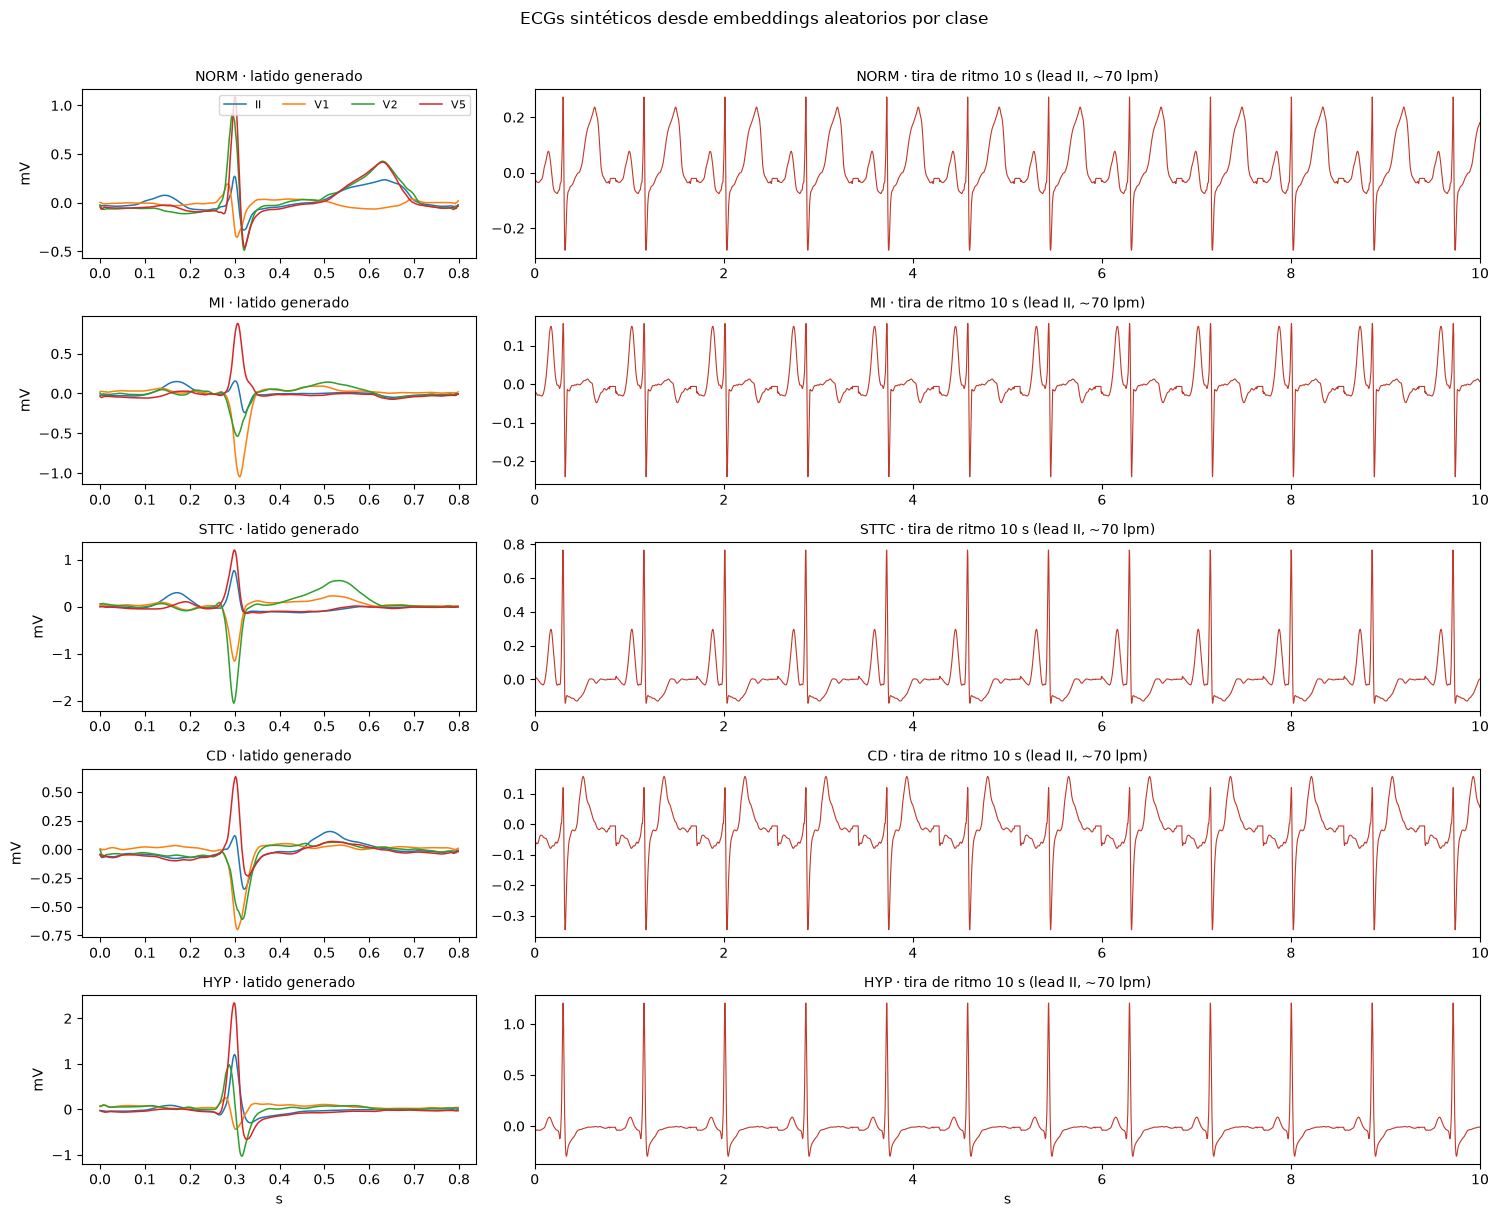

In [10]:
# Un latido generado por clase: PQRST en 4 derivaciones (izq) y tira de ritmo de 10 s, lead II (der)
rng = np.random.default_rng(SEED)
show_leads = [1, 6, 7, 10]                # II, V1, V2, V5
t_strip = np.arange(int(10 * fs)) / fs
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(15, 12),
                         gridspec_kw={"width_ratios": [1, 2.4]})
for (axb, axs), name in zip(axes, CLASSES):
    z = sample_embedding(name, n=1, scale=1.0, rng=rng)
    beat = decode(z)[0]                   # (12, BEAT_LEN) en mV
    for li in show_leads:
        axb.plot(t_beat, beat[li], lw=1.1, label=LEADS[li])
    axb.set_title(f"{name} · latido generado", fontsize=10); axb.set_ylabel("mV")
    axs.plot(t_strip, tile_beat(beat, seconds=10, bpm=70)[1], lw=0.8, color="#c0392b")
    axs.set_title(f"{name} · tira de ritmo 10 s (lead II, ~70 lpm)", fontsize=10)
    axs.set_xlim(0, 10)
axes[0, 0].legend(ncol=4, fontsize=8)
axes[-1, 0].set_xlabel("s"); axes[-1, 1].set_xlabel("s")
fig.suptitle("ECGs sintéticos desde embeddings aleatorios por clase", y=1.01)
plt.tight_layout(); plt.show()

### Juega con la generación

- `sample_embedding(clase, n, scale)`: sube `scale` (>1) para embeddings más "extremos" (más
  variabilidad, también más ruido); bájalo (<1) para algo cercano al latido **promedio** de la clase.
- `tile_beat(beat, seconds, bpm)`: cambia `bpm` para ver el mismo latido a distinto ritmo.
- También puedes interpolar entre dos clases: `z = a*mu_NORM + (1-a)*mu_MI` y decodificar para ver
  la transición morfológica del latido.

**Limitaciones que quedan:** el latido es **prototípico** (un solo latido representativo, sin
variabilidad latido-a-latido ni arritmias), y la gaussiana por dimensión ignora correlaciones entre
dimensiones del embedding. Para ECGs realistas, variados y de 10 s reales el siguiente paso natural
es un **VAE 1-D** o un modelo de **difusión** condicionado por clase sobre la señal completa.

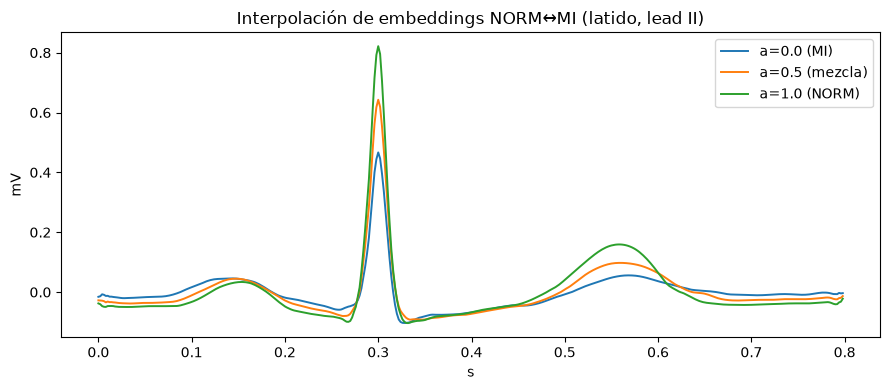

In [11]:
# Ejemplo: interpolación NORM -> MI en el latido (lead II)
mu_n, mu_m = class_stats["NORM"][0], class_stats["MI"][0]
fig, ax = plt.subplots(figsize=(9, 4))
for a in [0.0, 0.5, 1.0]:
    g = decode((a * mu_n + (1 - a) * mu_m)[None])[0]
    ax.plot(t_beat, g[1], lw=1.4, label=f"a={a} ({'NORM' if a==1 else 'MI' if a==0 else 'mezcla'})")
ax.set_title("Interpolación de embeddings NORM↔MI (latido, lead II)")
ax.set_xlabel("s"); ax.set_ylabel("mV"); ax.legend(); plt.tight_layout(); plt.show()